# 00 - Project Setup and Registry

This notebook prepares the project for the full MuJoCo benchmark workflow.

What this notebook does:

- verifies the Python/RL package versions used in the experiments
- checks that the MuJoCo environments load correctly
- displays the short sanity-run results
- audits the experiment registry and saved model artifacts
- confirms that checkpoints and final models are present before analysis

The output of this notebook is not a trained policy. Its purpose is to make sure
the experiment files are consistent before running the training and evaluation
notebooks.

## Load project utilities

This cell sets the working directory and imports the project helper module. The
helper module centralizes constants, model builders, evaluation functions, and
plotting utilities so the notebooks can focus on the experiment sequence.

In [1]:
from pathlib import Path
import os, sys, time, json

def find_project_root():
    for candidate in [Path.cwd(), Path.cwd().parent, Path(r"D:/MuJoCo_RL_Project")]:
        if (candidate / "project_utils.py").exists():
            return candidate.resolve()
    raise RuntimeError("project_utils.py was not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

import project_utils as pu
pu.set_plot_style()
pu.ensure_dirs()

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")


[project_utils] Loaded - Project root: D:\MuJoCo_RL_Project
  Python 3.10.20 | SB3 2.9.0 | Gymnasium 1.3.0
  Torch 2.12.1+cu126 | CUDA: True | GPU: NVIDIA RTX 5000 Ada Generation
Project root: D:\MuJoCo_RL_Project
Python: C:\Users\digilians01\.conda\envs\RL_PROJECT\python.exe


## Package versions

We record the main library versions used for the experiments. This matters for
reproducibility because MuJoCo, Gymnasium, Stable-Baselines3, PyTorch, and
SB3-Contrib can change behavior across versions.

In [2]:
import importlib, platform, torch

packages = ["gymnasium", "mujoco", "stable_baselines3", "sb3_contrib",
            "torch", "numpy", "pandas", "matplotlib", "scipy", "seaborn"]
rows = []
for package in packages:
    try:
        module = importlib.import_module(package)
        rows.append({"package": package, "version": getattr(module, "__version__", "installed")})
    except Exception as exc:
        rows.append({"package": package, "version": f"missing: {exc}"})

print(platform.platform())
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
display(pd.DataFrame(rows))


Windows-10-10.0.26200-SP0
CUDA available: True
GPU: NVIDIA RTX 5000 Ada Generation


,package,version
0,gymnasium,1.3.0
1,mujoco,3.10.0
2,stable_baselines3,2.9.0
3,sb3_contrib,2.9.0
4,torch,2.12.1+cu126
5,numpy,2.2.5
6,pandas,2.3.3
7,matplotlib,3.10.9
8,scipy,1.15.3
9,seaborn,0.13.2


## Environment check

This confirms that all three MuJoCo environments can be created and that their
observation/action spaces match the benchmark setup.

In [3]:
import gymnasium as gym

env_rows = []
for env_id in pu.ENV_IDS:
    env = gym.make(env_id)
    env_rows.append({
        "env_id": env_id,
        "observation_shape": env.observation_space.shape,
        "action_shape": env.action_space.shape,
        "max_episode_steps": getattr(env.spec, "max_episode_steps", None),
    })
    env.close()
display(pd.DataFrame(env_rows))


,env_id,observation_shape,action_shape,max_episode_steps
0,HalfCheetah-v5,"(17,)","(6,)",1000
1,Hopper-v5,"(11,)","(3,)",1000
2,Walker2d-v5,"(17,)","(6,)",1000


## Sanity check results

The sanity run is a small 5k-step training pass used only to confirm that the
training loop, environment stepping, model construction, and evaluation path all
work before running the long experiments.

In [4]:
sanity_path = pu.RESULTS_RAW / "sanity_check.csv"
if sanity_path.exists():
    sanity_df = pd.read_csv(sanity_path)
    print(f"Loaded: {sanity_path}")
else:
    sanity_df = pd.DataFrame()
    print("Sanity CSV is missing. Run the short sanity block from the old setup notebook if needed.")
display(sanity_df)


Loaded: D:\MuJoCo_RL_Project\results\raw\sanity_check.csv


,environment,algorithm,seed,timesteps,mean_reward,std_reward,wall_clock_seconds,status
0,HalfCheetah-v5,PPO,42,5000,-0.816181,0.233722,8.72,OK
1,HalfCheetah-v5,SAC,42,5000,-71.942976,1.458054,36.43,OK
2,HalfCheetah-v5,TD3,42,5000,-296.492792,27.243585,17.98,OK
3,HalfCheetah-v5,DDPG,42,5000,-470.062337,85.585057,18.49,OK
4,HalfCheetah-v5,TQC,42,5000,-119.400073,18.988804,36.35,OK
5,Hopper-v5,PPO,42,5000,56.655165,0.164542,9.34,OK
6,Hopper-v5,SAC,42,5000,184.664017,0.537183,35.39,OK
7,Hopper-v5,TD3,42,5000,90.235103,0.459883,17.87,OK
8,Hopper-v5,DDPG,42,5000,2.595805,0.092418,18.88,OK
9,Hopper-v5,TQC,42,5000,251.242639,0.278132,37.95,OK


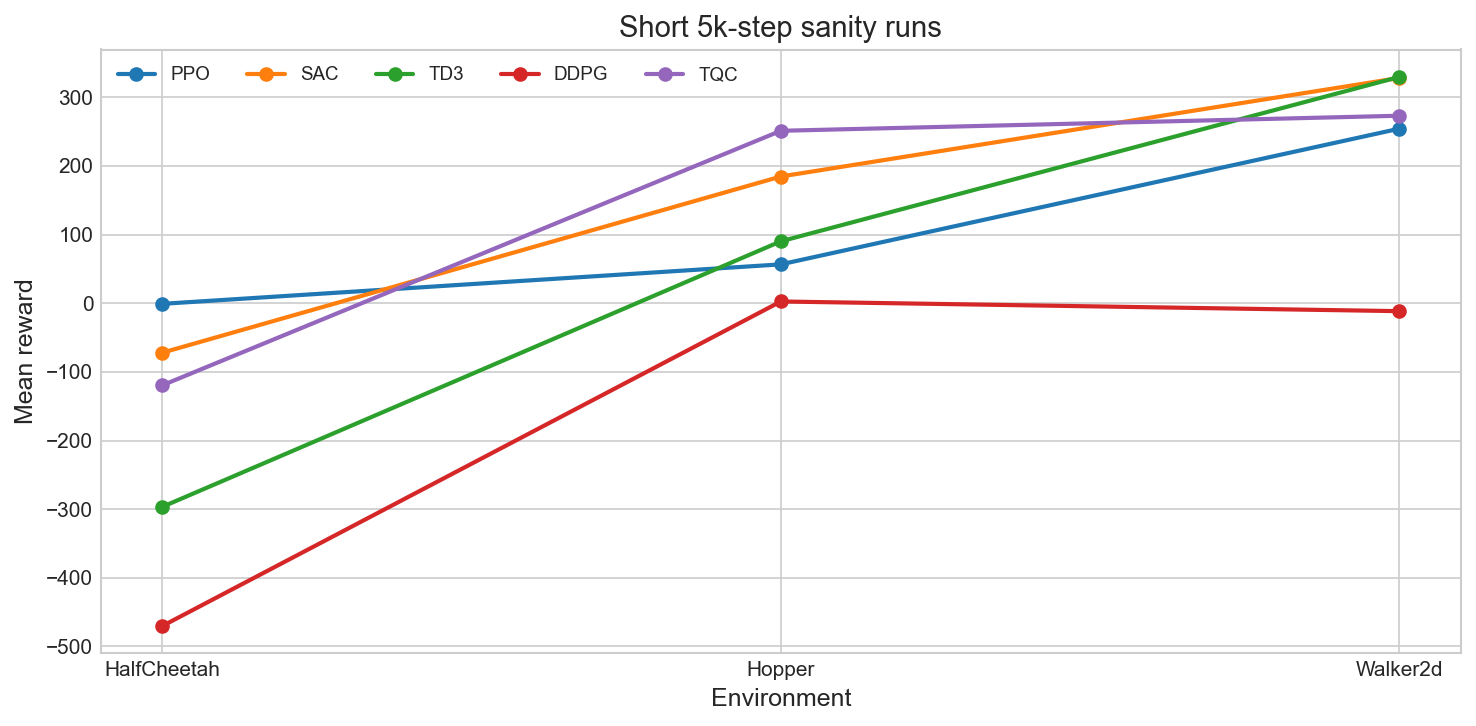

In [5]:
if not sanity_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    for algo in pu.ALGORITHMS:
        part = sanity_df[sanity_df["algorithm"] == algo]
        ax.plot(part["environment"].str.replace("-v5", "", regex=False),
                part["mean_reward"], marker="o", label=algo)
    ax.set_title("Short 5k-step sanity runs")
    ax.set_xlabel("Environment")
    ax.set_ylabel("Mean reward")
    ax.legend(ncol=5, fontsize=9)
    plt.tight_layout()
    plt.show()


## Experiment registry status

The registry is the experiment ledger. Each row corresponds to a run and records
the algorithm, environment, seed, track, model path, and completion status.

The counts below confirm that the main benchmark grid is complete before the
analysis notebooks are run.

In [6]:
registry = pu.load_registry()
print(f"Registry rows: {len(registry)}")
display(registry.groupby(["track", "status"]).size().unstack(fill_value=0))

for track in ["default_1m", "tuned_screen", "tuned_1m"]:
    part = registry[(registry["track"] == track) & (registry["status"] == "complete")]
    if track == "default_1m":
        headline = part[part["seed"] < pu.N_DEFAULT_SEEDS]
        expected = len(pu.ALGORITHMS) * len(pu.ENV_IDS) * pu.N_DEFAULT_SEEDS
    elif track == "tuned_screen":
        headline = part
        expected = 54
    else:
        headline = part
        expected = len(pu.ALGORITHMS) * len(pu.ENV_IDS) * len(pu.SEEDS_FINAL)
    print(f"{track:13s}: {len(headline)}/{expected} complete")


Registry rows: 353


status,complete
track,
default_1m,51
diagnostic_250k,75
diagnostic_500k,10
legacy_1m,118
tuned_1m,45
tuned_screen,54


default_1m   : 45/45 complete
tuned_screen : 54/54 complete
tuned_1m     : 45/45 complete


## Model and checkpoint inventory

This inventory shows how many model files, checkpoints, replay buffers, and
normalization files are available. It is a practical check that the saved
artifacts needed for reruns and evaluation are present.

In [7]:
rows = []
for folder in sorted(pu.MODELS_DIR.iterdir()):
    if not folder.is_dir():
        continue
    files = [p for p in folder.rglob("*") if p.is_file()]
    rows.append({
        "folder": folder.name,
        "zip_files": sum(p.suffix == ".zip" for p in files),
        "resume_json": sum(p.name.endswith("resume_state.json") for p in files),
        "replay_buffers": sum(p.name.endswith("replay_buffer.pkl") for p in files),
        "vecnormalize": sum(p.name.endswith("vecnormalize.pkl") for p in files),
        "size_gb": round(sum(p.stat().st_size for p in files) / 1024**3, 2),
    })
display(pd.DataFrame(rows))


,folder,zip_files,resume_json,replay_buffers,vecnormalize,size_gb
0,default_1m,578,51,426,0,109.57
1,extended_2m,0,0,0,0,0.00
2,HalfCheetah-v5,83,0,0,10,0.24
3,Hopper-v5,76,0,0,10,0.24
4,tuned_1m,506,45,361,108,93.09
5,tuned_screen,223,54,144,30,37.25
6,Walker2d-v5,44,0,0,10,0.11
